In [1]:
import pandas as pd
import anndata as ad
import numpy as np
import pickle
import sys

from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2

sys.path.append("/home/liyang/BioWuYan/MethodTest/dygmamba/src")

from analysis.assess import auc_plot, pr_plot, calculate_max_f_beta
from data_preprocess import adata_to_dataframe

assess_result = "/home/liyang/BioWuYan/MethodTest/assess_result4/"

import os
os.makedirs(assess_result, exist_ok= True)

# Load common data

In [2]:
data_path = "/home/liyang/BioWuYan/MethodTest/Data/All2/0process/"

adata_rna = ad.read_h5ad(data_path + "rna_processed.h5ad")

adata_atac = ad.read_h5ad(data_path + "atac_processed.h5ad")

# Load Benchmark Data

In [6]:
from data_preprocess import adata_to_dataframe

benchmark_data_path = "/home/liyang/BioWuYan/MethodTest/Data/All2/0process/"

benchmark_tf_gene_grn = ad.read_h5ad(benchmark_data_path + "tf_gene_network.h5ad")

benchmark_peak_gene_grn = ad.read_h5ad(benchmark_data_path + "peak_gene_network.h5ad")

benchmark_tf_peak_grn = ad.read_h5ad(benchmark_data_path + "tf_peak_network.h5ad")



benchmark_tf_gene_df = adata_to_dataframe(benchmark_tf_gene_grn)

benchmark_tf_gene_df.head()
benchmark_tf_gene_df = benchmark_tf_gene_df.rename(columns= {"obs":"TF", "var":"Gene"})
print(benchmark_tf_gene_df)
benchmark_tf_gene_threshold = 5

             TF  Gene  value
0         NR3C1  AAAS     14
1          RFX1  AAAS     70
2          NFYA  AAAS    119
3         SOX13  AAAS    256
4          E2F8  AAAS    114
...         ...   ...    ...
223903    ESRRA   ZYX    235
223904     ELF1   ZYX    495
223905     CREM   ZYX    415
223906  BHLHE40   ZYX    412
223907     ARNT   ZYX    377

[223908 rows x 3 columns]


# Load DyGMamba Data

In [5]:
dygmamba_data_path = "/home/liyang/BioWuYan/MethodTest/dygmamba/res/result2/"

###########################################################
# load data
feat_path = dygmamba_data_path + "edge_features.npy"
edge_label_path = dygmamba_data_path + "edge_labels.npy"

Edge_feature = np.load(feat_path, mmap_mode="r")
Edge_feature = Edge_feature.reshape(-1,1).copy()
Edge_label = np.load(edge_label_path, mmap_mode="r")
Edge_label = Edge_label.reshape(-1,1).copy()

with open(dygmamba_data_path + "node_feature_data.pkl", "rb") as f:
    load_data = pickle.load(f)

Node_feature = load_data['node_feature']

Node_id = pd.read_pickle(dygmamba_data_path + "node_id.pkl")

graph_df = pd.read_pickle(dygmamba_data_path + "Graph_df.pkl")
graph_df["Unnamed"] = graph_df.index
name_list = ["Unnamed", "source_node", "target_node", "time", "label", "edge_idx"]
New_Graph = graph_df[name_list].copy()
New_Graph.columns = ['Unnamed: 0', 'u', 'i', 'ts', 'label', 'idx']


In [6]:

dygmamba_tf_peak_df = pd.read_pickle(dygmamba_data_path + "tf_region_grn.pkl")

dygmamba_peak_gene_df = pd.read_pickle(dygmamba_data_path + "region_gene_grn.pkl")

dygmamba_tf_gene_df = pd.read_pickle(dygmamba_data_path + "new_tf_gene_grn.pkl")

dygmamba_avg_tf_gene_df = pd.read_pickle(dygmamba_data_path + "average_tf_gene_grn.pkl")


In [7]:
dygmamba_peak_gene_df = dygmamba_peak_gene_df[["source", "target", "ts", "label", "predict"]]
dygmamba_peak_gene_df.rename(columns={"source": "Peak", "target":"Gene"})

# 使用这个条件过滤 DataFrame，只保留 'Gene' 不以 'chr' 开头的行
# 这里指考虑TF-Gene, 不考虑TF-peak
condition = ~(dygmamba_tf_gene_df['Gene'].str.startswith('chr'))
dygmamba_tf_gene_grn = dygmamba_tf_gene_df[condition]

print(dygmamba_tf_gene_grn)

condition = ~(dygmamba_avg_tf_gene_df['Gene'].str.startswith('chr'))
dygmamba_avg_tf_gene_grn = dygmamba_avg_tf_gene_df[condition]

print(dygmamba_avg_tf_gene_grn)

              TF    Gene         ts  peak_num
0           ALX3    AAAS   0.103799         1
1           ALX3    AAAS   0.130393         2
2           ALX3    AAAS   0.427715         2
3           ALX3    AAAS   0.487691         2
4           ALX3    AAAS   0.539682         1
...          ...     ...        ...       ...
328487742  mix-a  ZSWIM1  10.038790         1
328487743  mix-a  ZSWIM1  10.113001         1
328487744  mix-a  ZSWIM1  10.506163         1
328487745  mix-a  ZSWIM1  10.584224         1
328487746  mix-a  ZSWIM1  10.729193         1

[21450157 rows x 4 columns]
ts                   TF   Gene  average_peak_num
3101809  Stat5a::Stat5b  VEGFB          3.318386
3631275           ZNF16  VEGFB          3.318386
240744            CEBPD  VEGFB          3.318386
2613740           PRRX2  VEGFB          3.318386
2169250           NR2C2  VEGFB          3.318386
...                 ...    ...               ...
870558            FOXB1   CCR8          0.228700
2432813            PAX9   C

In [8]:
print(dygmamba_tf_peak_df.head())

print(dygmamba_peak_gene_df.head())

print(dygmamba_tf_gene_df.head())

print(dygmamba_avg_tf_gene_df.head())

               Peak      TF  value
0  chr1-10231-10656   Dmrt1      1
1  chr1-10231-10656  ZNF708      1
2  chr1-10231-10656    CDX2      1
3  chr1-10231-10656    Lef1      1
4  chr1-10231-10656     SP1      1
                    source target        ts  label  predict
1  chr12-53370831-53371774   AAAS  0.130393      1        1
2  chr12-53370831-53371774   AAAS  0.427715      1        1
3  chr12-53370831-53371774   AAAS  0.487691      1        1
4  chr12-53370831-53371774   AAAS  0.560851      1        1
5  chr12-53370831-53371774   AAAS  0.756194      1        1
     TF  Gene        ts  peak_num
0  ALX3  AAAS  0.103799         1
1  ALX3  AAAS  0.130393         2
2  ALX3  AAAS  0.427715         2
3  ALX3  AAAS  0.487691         2
4  ALX3  AAAS  0.539682         1
ts                   TF   Gene  average_peak_num
3101809  Stat5a::Stat5b  VEGFB          3.318386
3631275           ZNF16  VEGFB          3.318386
240744            CEBPD  VEGFB          3.318386
2613740           PRRX2  VEGFB

# Assess

In [9]:
##############################################################################################
# ************************ Benchmark Data **************
benchmark_data_path = "/home/liyang/BioWuYan/MethodTest/Data/All2/0process/"

benchmark_tf_gene_grn = ad.read_h5ad(benchmark_data_path + "tf_gene_network.h5ad")

benchmark_peak_gene_grn = ad.read_h5ad(benchmark_data_path + "peak_gene_network.h5ad")

benchmark_tf_peak_grn = ad.read_h5ad(benchmark_data_path + "tf_peak_network.h5ad")
    
benchmark_tf_gene_df = adata_to_dataframe(benchmark_tf_gene_grn)

benchmark_tf_gene_df = benchmark_tf_gene_df.rename(columns= {"obs":"TF", "var":"Gene"})

##############################################################################################
# ************************ dygmamba Data **************

dygmamba_data_path = "/home/liyang/BioWuYan/MethodTest/dygmamba/res/result2/"

dygmamba_tf_peak_df = pd.read_pickle(dygmamba_data_path + "tf_region_grn.pkl")

dygmamba_peak_gene_df = pd.read_pickle(dygmamba_data_path + "region_gene_grn.pkl")

dygmamba_tf_gene_df = pd.read_pickle(dygmamba_data_path + "new_tf_gene_grn.pkl")

dygmamba_avg_tf_gene_df = pd.read_pickle(dygmamba_data_path + "average_tf_gene_grn.pkl")


dygmamba_peak_gene_df = dygmamba_peak_gene_df[["source", "target", "ts", "label", "predict"]]
dygmamba_peak_gene_df.rename(columns={"source": "Peak", "target":"Gene"})

# 使用这个条件过滤 DataFrame，只保留 'Gene' 不以 'chr' 开头的行
# 这里指考虑TF-Gene, 不考虑TF-peak
condition = ~(dygmamba_tf_gene_df['Gene'].str.startswith('chr'))
dygmamba_tf_gene_grn = dygmamba_tf_gene_df[condition]

print("********************** TF-Gene for each time **********************************")
print(dygmamba_tf_gene_grn.head())

condition = ~(dygmamba_avg_tf_gene_df['Gene'].str.startswith('chr'))
dygmamba_avg_tf_gene_grn = dygmamba_avg_tf_gene_df[condition]

print("********************** TF-Gene for average **********************************")
print(dygmamba_avg_tf_gene_grn.head())

##############################################################################################
# =================== result analysis ===================
##############################################################################################
dygmamba_avg_tf_gene_grn.columns.name = ""
dygmamba_avg_tf_gene_grn = dygmamba_avg_tf_gene_grn.reset_index()
dygmamba_avg_tf_gene_grn = dygmamba_avg_tf_gene_grn.drop(["index"],axis = 1)
dygmamba_avg_tf_gene_grn["predict_label"] = (dygmamba_avg_tf_gene_grn["average_peak_num"]>1).astype(int)

dyg_merged_data = pd.merge(benchmark_tf_gene_df, dygmamba_avg_tf_gene_grn, on = ["TF", "Gene"], how="outer").fillna(0)
dyg_merged_data["label"] = (dyg_merged_data["value"] > benchmark_tf_gene_threshold).astype(int)

dyg_merge_grn = dyg_merged_data[dyg_merged_data["value"] > benchmark_tf_gene_threshold].copy()

dyg_y_true = dyg_merged_data["label"].astype(int)
dyg_y_pre = dyg_merged_data["predict_label"].astype(int)

auc_value = roc_auc_score(dyg_y_true, dyg_y_pre)
aupr_value = average_precision_score(dyg_y_true, dyg_y_pre)

print(f"AUC of DygMamba is {auc_value}, AUPR is {aupr_value}")

********************** TF-Gene for each time **********************************
     TF  Gene        ts  peak_num
0  ALX3  AAAS  0.103799         1
1  ALX3  AAAS  0.130393         2
2  ALX3  AAAS  0.427715         2
3  ALX3  AAAS  0.487691         2
4  ALX3  AAAS  0.539682         1
********************** TF-Gene for average **********************************
ts                   TF   Gene  average_peak_num
3101809  Stat5a::Stat5b  VEGFB          3.318386
3631275           ZNF16  VEGFB          3.318386
240744            CEBPD  VEGFB          3.318386
2613740           PRRX2  VEGFB          3.318386
2169250           NR2C2  VEGFB          3.318386
AUC of DygMamba is 0.4243813682399949, AUPR is 0.5636942941369923


## TF Assess

### AUC & PR

#### DyGMamba

save fig as /home/liyang/BioWuYan/MethodTest/assess_result/Dygmamba_roc_curve.png


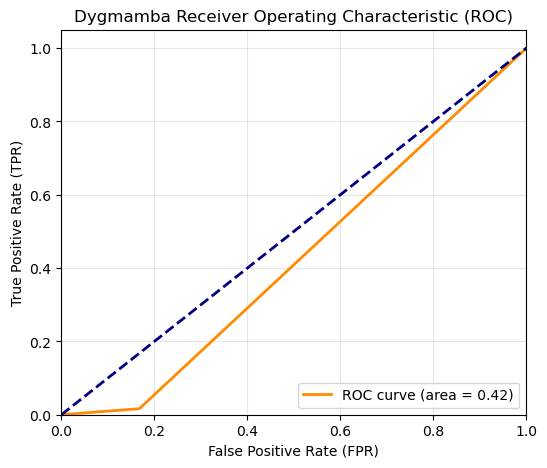

save fig as /home/liyang/BioWuYan/MethodTest/assess_result/Dygmamba_pr_curve.png


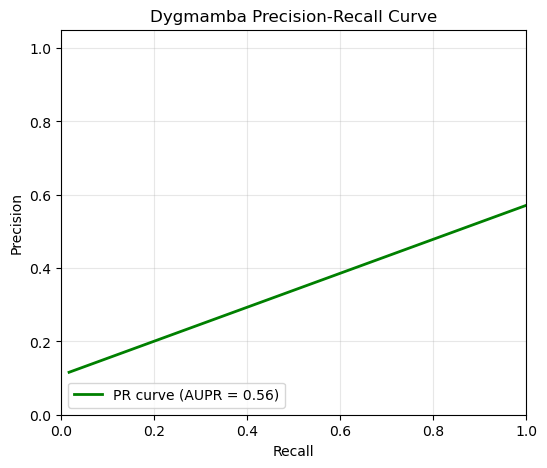

AUC of DygMamba is 0.4243813682399949, AUPR is 0.5636942941369923
 DyGMamba F1_score is 0.5736368686920282


In [10]:
dygmamba_avg_tf_gene_grn.columns.name = ""
dygmamba_avg_tf_gene_grn = dygmamba_avg_tf_gene_grn.reset_index()
dygmamba_avg_tf_gene_grn = dygmamba_avg_tf_gene_grn.drop(["index"],axis = 1)
dygmamba_avg_tf_gene_grn["predict_label"] = (dygmamba_avg_tf_gene_grn["average_peak_num"]>1).astype(int)

dyg_merged_data = pd.merge(benchmark_tf_gene_df, dygmamba_avg_tf_gene_grn, on = ["TF", "Gene"], how="outer").fillna(0)
dyg_merged_data["label"] = (dyg_merged_data["value"] > benchmark_tf_gene_threshold).astype(int)

dyg_merge_grn = dyg_merged_data.copy()
# dyg_merged_data["value"].plot(kind='hist', bins=100)
# print(benchmark_tf_gene_df.head())
# print(dygmamba_avg_tf_gene_grn.head())

dyg_y_true = dyg_merge_grn["label"].astype(int)
dyg_y_pre = dyg_merge_grn["predict_label"].astype(int)

if sum(dyg_y_true) == len(dyg_y_true) or sum(dyg_y_true) == 0:
    auc_value = 0
    print(" *********************** sample are all true/false************************************** ")
else:
    auc_value = roc_auc_score(dyg_y_true, dyg_y_pre)
    auc_plot(dyg_y_true, dyg_y_pre,fig_title = "Dygmamba", fig_path = assess_result)


aupr_value = average_precision_score(dyg_y_true, dyg_y_pre)

pr_plot(dyg_y_true, dyg_y_pre, fig_title = "Dygmamba", fig_path = assess_result)

print(f"AUC of DygMamba is {auc_value}, AUPR is {aupr_value}")

precision, recall, thresholds = precision_recall_curve(dyg_y_true, dyg_y_pre)
f01_score, best_thresh = calculate_max_f_beta(precision, recall, thresholds, beta=0.1)

print(f" DyGMamba F1_score is {f01_score}")



#### Celloracle

save fig as /home/liyang/BioWuYan/MethodTest/assess_result/Celloracle_roc_curve.png


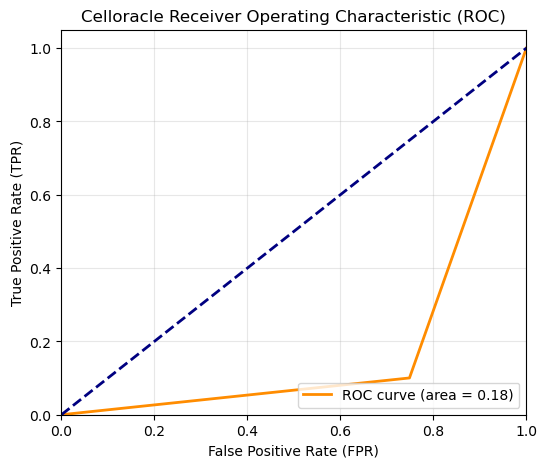

save fig as /home/liyang/BioWuYan/MethodTest/assess_result/Celloracle_pr_curve.png


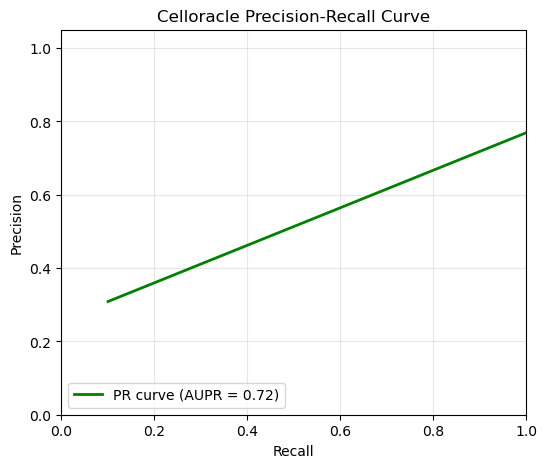

AUC of Celloracle is 0.17588054471225317, AUPR is 0.7230888734572467


In [14]:
oracle_data_path = '/home/liyang/BioWuYan/MethodTest/celloracle/result/'

celloracle_grn = pd.read_csv(oracle_data_path + "celloracle_results/grn_df_" + "cluster0" + ".csv")

celloracle_grn.rename(columns={"source": "TF", "target": "Gene"}, inplace= True)

oracle_tf_gene = celloracle_grn[["TF", "Gene", "-logp"]].copy()

oracle_merged_df = pd.merge(benchmark_tf_gene_df, oracle_tf_gene, on = ["TF", "Gene"], how="outer").fillna(0)

oracle_merged_df["label"] = (oracle_merged_df["value"] > benchmark_tf_gene_threshold).astype(int)

oracle_merged_grn = oracle_merged_df.copy()

oracle_merged_grn["predict_label"] = (oracle_merged_grn["-logp"] > 1.3).astype(int)


oracle_y_true = oracle_merged_grn["label"].astype(int)
oracle_y_pre = oracle_merged_grn["predict_label"].astype(int)

auc_value = roc_auc_score(oracle_y_true, oracle_y_pre)
auc_plot(oracle_y_true, oracle_y_pre,fig_title = "Celloracle", fig_path = assess_result)

aupr_value = average_precision_score(oracle_y_true, oracle_y_pre)
pr_plot(oracle_y_true, oracle_y_pre, fig_title = "Celloracle", fig_path = assess_result)

print(f"AUC of Celloracle is {auc_value}, AUPR is {aupr_value}")


In [15]:
precision, recall, thresholds = precision_recall_curve(oracle_y_true, oracle_y_pre)
f01_score, best_thresh = calculate_max_f_beta(precision, recall, thresholds, beta=0.1)

print(f" Cleeoracle F1_score is {f01_score}")

 Cleeoracle F1_score is 0.7710276546374552


#### scGLUE

save fig as /home/liyang/BioWuYan/MethodTest/assess_result/glue_roc_curve.png


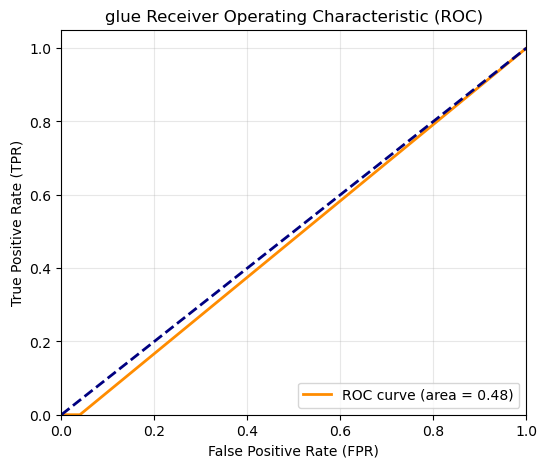

save fig as /home/liyang/BioWuYan/MethodTest/assess_result/glue_pr_curve.png


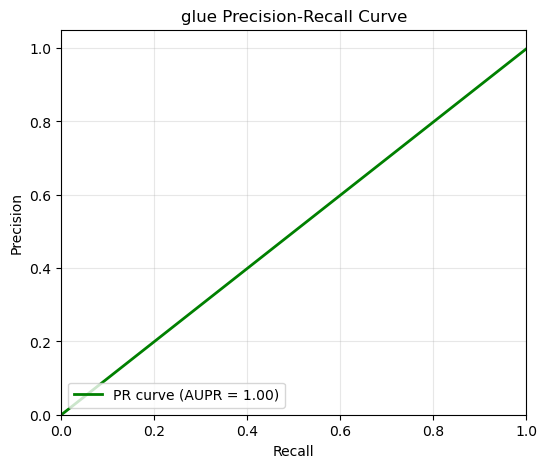

AUC of scGLUE is 0.48009367681498827, AUPR is 0.9980931115328793


In [16]:
from analysis.assess import glue_read_full_grn

glue_data_path = "/home/liyang/BioWuYan/MethodTest/new_scglue/result/"

glue_df = glue_read_full_grn(glue_data_path + 'pruned_grn.csv')

glue_df = glue_df[['TF', 'Target', 'Importance', 'MotifID', 'NES', 'AUC', 'RankAtMax', 'MotifSimilarityQvalue', 'Annotation']]
glue_df.drop_duplicates(subset=['TF', 'Target'], inplace=True)

glue_grn = glue_df[["TF","Target","Importance"]].rename(columns = {"Target":"Gene"})

glue_merged_grn = pd.merge(benchmark_tf_gene_df, glue_grn, on = ["TF", "Gene"], how="outer").fillna(0)
glue_merged_grn["predict_label"] = (glue_merged_grn["Importance"]>0).astype(int)
glue_merged_grn["label"] = (glue_merged_grn["value"]>benchmark_tf_gene_threshold).astype(int)

glue_y_true = glue_merged_grn["label"].astype(int)
glue_y_pre = glue_merged_grn["predict_label"].astype(int)

auc_value = roc_auc_score(glue_y_true, glue_y_pre)
auc_plot(glue_y_true, glue_y_pre,fig_title = "glue", fig_path = assess_result)

aupr_value = average_precision_score(glue_y_true, glue_y_pre)
pr_plot(glue_y_true, glue_y_pre, fig_title = "glue", fig_path = assess_result)

print(f"AUC of scGLUE is {auc_value}, AUPR is {aupr_value}")

In [17]:
glue_precision, glue_recall, glue_thresholds = precision_recall_curve(glue_y_true, glue_y_pre)
glue_f01_score, glue_best_thresh = calculate_max_f_beta(glue_precision, glue_recall, glue_thresholds, beta=0.1)

print(f" Cleeoracle F1_score is {glue_f01_score}")

 Cleeoracle F1_score is 0.9981119559702826


#### Pando

save fig as /home/liyang/BioWuYan/MethodTest/assess_result/pando_roc_curve.png


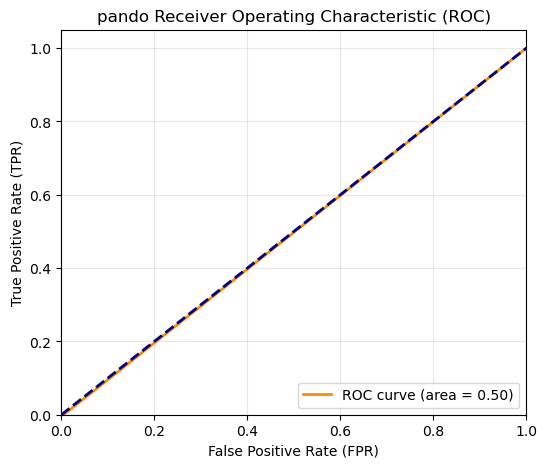

save fig as /home/liyang/BioWuYan/MethodTest/assess_result/pando_pr_curve.png


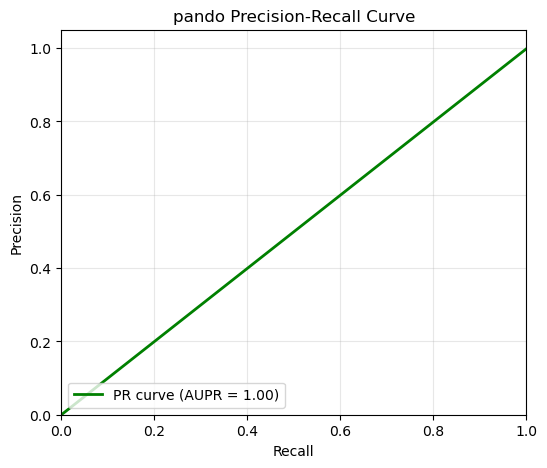

AUC of Pando is 0.4975728155339806, AUPR is 0.9981599749899513
 Pando F1_score is 0.9981781598689478


In [18]:
pando_df = pd.read_csv("/home/liyang/BioWuYan/MethodTest/Pando/result/grn.csv")
pando_grn = pando_df[["tf","target","pval"]].copy()
pando_grn.rename(columns={"tf": "TF", "target": "Gene"},inplace=True)
pando_grn['-log10p'] = -np.log10(pando_grn['pval'])

pando_merged_grn = pd.merge(benchmark_tf_gene_df, pando_grn, on = ["TF", "Gene"], how="outer").fillna(0)
pando_merged_grn["label"] = (pando_merged_grn["value"]> benchmark_tf_gene_threshold).astype(int)
pando_merged_grn["predict_label"] = (pando_merged_grn["-log10p"]> 1.3).astype(int)

pando_y_true = pando_merged_grn["label"].astype(int)
pando_y_pre = pando_merged_grn["predict_label"].astype(int)

auc_value = roc_auc_score(pando_y_true, pando_y_pre)
auc_plot(pando_y_true, pando_y_pre,fig_title = "pando", fig_path = assess_result)

aupr_value = average_precision_score(pando_y_true, pando_y_pre)
pr_plot(pando_y_true, pando_y_pre, fig_title = "pando", fig_path = assess_result)

print(f"AUC of Pando is {auc_value}, AUPR is {aupr_value}")

pando_precision, pando_recall, pando_thresholds = precision_recall_curve(pando_y_true, pando_y_pre)
pando_f01_score, pando_best_thresh = calculate_max_f_beta(pando_precision, pando_recall, pando_thresholds, beta=0.1)

print(f" Pando F1_score is {pando_f01_score}")


## TF recovery

In [16]:
from analysis.assess import calculate_tf_recovery


### DyGMamba

Gold Standard 中共有 112 个唯一 TF。
未检测到分数列，将按 TF 的靶基因数量 (Degree) 进行排序。
save fig as /home/liyang/BioWuYan/MethodTest/assess_result/Dygmamba_TF_recovery_curve.png


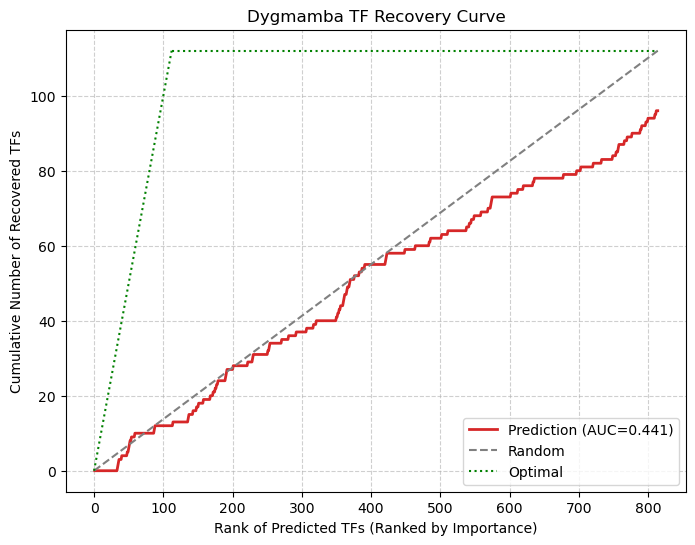

In [17]:
dyg_grn_df = dyg_merged_data[["TF", "Gene", "predict_label"]]
dyg_grn = dyg_grn_df[dyg_grn_df["predict_label"] ==1 ].copy()
gold_grn_df = dyg_merged_data[["TF", "Gene", "label"]]
gold_grn = gold_grn_df[gold_grn_df["label"] ==1].copy()

x, y, score_auc, total_gold = calculate_tf_recovery(dyg_grn, gold_grn, fig_title = "Dygmamba", fig_path = assess_result)

### glue

Gold Standard 中共有 112 个唯一 TF。
未检测到分数列，将按 TF 的靶基因数量 (Degree) 进行排序。
save fig as /home/liyang/BioWuYan/MethodTest/assess_result/glue_TF_recovery_curve.png


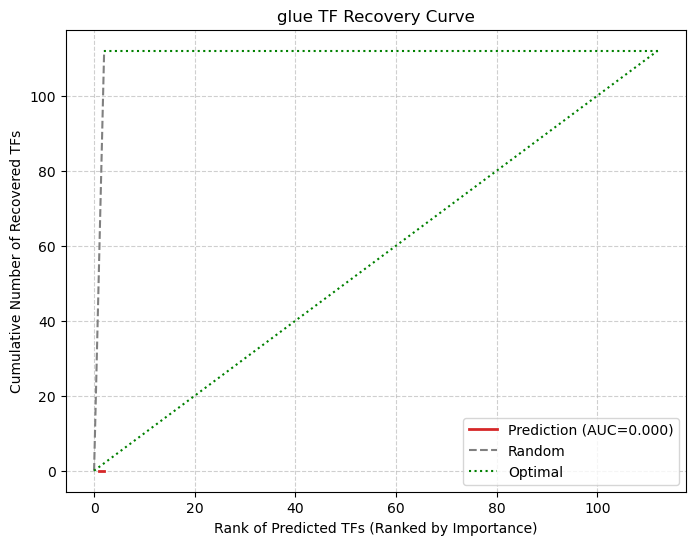

In [18]:
glue_grn_df = glue_merged_grn[["TF", "Gene", "predict_label"]]
glue_grn = glue_grn_df[glue_grn_df["predict_label"] ==1 ].copy()
gold_grn_df = glue_merged_grn[["TF", "Gene", "label"]]
gold_grn = gold_grn_df[gold_grn_df["label"] ==1].copy()

x, y, score_auc, total_gold = calculate_tf_recovery(glue_grn, gold_grn, fig_title = "glue", fig_path = assess_result)

### Celloracle

Gold Standard 中共有 112 个唯一 TF。
未检测到分数列，将按 TF 的靶基因数量 (Degree) 进行排序。
save fig as /home/liyang/BioWuYan/MethodTest/assess_result/oracle_TF_recovery_curve.png


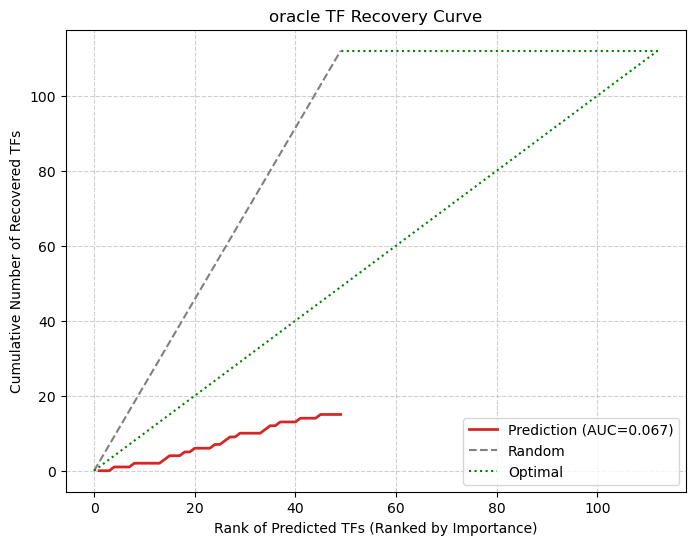

In [19]:
oracle_grn_df = oracle_merged_grn[["TF", "Gene", "predict_label"]]
oracle_grn = oracle_grn_df[oracle_grn_df["predict_label"] ==1 ].copy()
gold_grn_df = oracle_merged_grn[["TF", "Gene", "label"]]
gold_grn = gold_grn_df[gold_grn_df["label"] ==1].copy()

x, y, score_auc, total_gold = calculate_tf_recovery(oracle_grn, gold_grn, fig_title = "oracle", fig_path = assess_result)

### Pando

Gold Standard 中共有 112 个唯一 TF。
未检测到分数列，将按 TF 的靶基因数量 (Degree) 进行排序。
save fig as /home/liyang/BioWuYan/MethodTest/assess_result/pando_TF_recovery_curve.png


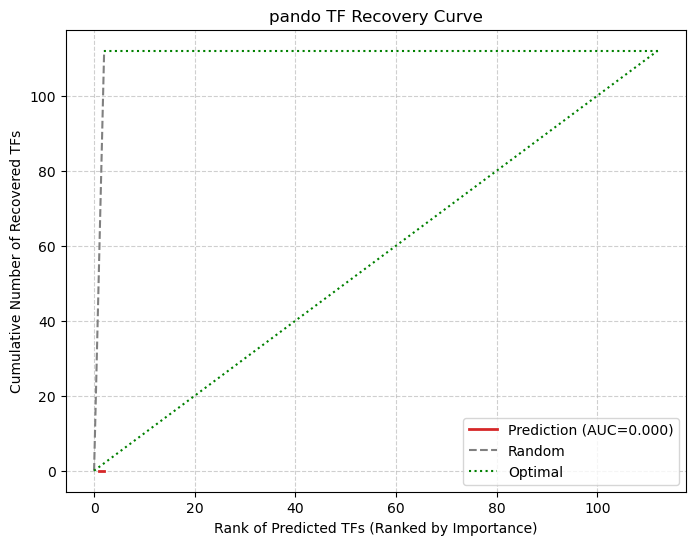

In [20]:
pando_grn_df = pando_merged_grn[["TF", "Gene", "predict_label"]]
pando_grn = pando_grn_df[pando_grn_df["predict_label"] ==1 ].copy()
gold_grn_df = pando_merged_grn[["TF", "Gene", "label"]]
gold_grn = gold_grn_df[gold_grn_df["label"] ==1].copy()

x, y, score_auc, total_gold = calculate_tf_recovery(pando_grn, gold_grn, fig_title = "pando", fig_path = assess_result)

## Other


## tispec tau
这里我们先对每个基因计算一个tau值
 $$
  \tau = \frac{\sum(1 - \hat{x}_i)} {N - 1}
 $$

 其中，$\hat{x}_i = \frac{x_i}{\max(\mathbf{x}_i)}$

 然后再计算加权tau值
 $$
 \hat{tau} = tau \frac{x_i}{\max(\mathbf{x}_i)}
 $$

In [21]:
def calc_tau(x: pd.DataFrame) -> pd.DataFrame:
    """
    Python 实现的 calcTau 函数 (组织特异性计算)。
    
    参数:
        x: pd.DataFrame, 行为基因，列为组织。输入应为 Quantile Normalized 后的数据。
        
    返回:
        pd.DataFrame: 第一列为 'tau' (总体特异性)，后续列为各组织的特异性分数。
    """
    df = x.copy()
    
    # ---------------------------------------------------------
    # 1. Binning (分箱): 将连续表达量转换为 0-10 的等级
    # ---------------------------------------------------------
    # 创建一个空的 DataFrame 存放 bin 结果
    bin_df = pd.DataFrame(index=df.index, columns=df.columns)
    
    for col in df.columns:
        # 取出当前组织的数据
        series = df[col]
        
        # 提取非零值计算分位数 (与 R 代码逻辑一致)
        non_zero_values = series[series != 0]
        
        if len(non_zero_values) == 0:
            # 如果全为0，则 bin 也全为 0
            bin_df[col] = 0
            continue
            
        # 计算 10% 到 90% 的分位点
        decile_limits = np.quantile(non_zero_values, np.arange(0.1, 1.0, 0.1))
        
        # 计算等级 (digitize 返回的是索引，0代表小于第一个分位数)
        # R 代码逻辑：
        # x=0 -> bin=0
        # x > 0 且 x < 10% -> bin=1
        # ...
        # numpy.digitize 默认 bins[i-1] <= x < bins[i]，我们需要稍作调整以匹配 R 的 sum(x > limit)
        # 实际上 sum(x > limits) + 1 等价于 np.digitize(x, limits) + 1 (如果 x 不为0)
        
        # 先对所有数进行分箱
        bins = np.digitize(series, decile_limits) + 1
        
        # 将原始值为 0 的位置强制设为等级 0 (匹配 R 的 x[is.na(x)] <- 0)
        bins[series == 0] = 0
        
        bin_df[col] = bins

    # 确保 bin_df 为数值型
    bin_df = bin_df.astype(float)

    # ---------------------------------------------------------
    # 2. 计算 Tau Index
    # Formula: sum(1 - (bin / max_bin)) / (N_tissues - 1)
    # ---------------------------------------------------------
    # 计算每一行（基因）的最大等级
    row_max_bins = bin_df.max(axis=1)
    
    # 避免除以 0 (如果一行全为0，max也是0)
    row_max_bins[row_max_bins == 0] = 1.0 
    
    # 计算 Tau
    # N_tissues 是列数
    n_tissues = bin_df.shape[1]
    
    # 向量化计算
    # (1 - (每个bin / 该行最大bin)) 对行求和，再除以 N-1
    tau_values = (1 - bin_df.div(row_max_bins, axis=0)).sum(axis=1) / (n_tissues - 1)
    
    # 处理全 0 行产生的计算异常（理论上逻辑正确，但也可能 Tau 需设为 NaN 或 0）
    # R代码中如果 bin 全为0，rowSums(1-0/0) 会出问题，但通常基因过滤会去掉全0行。
    # 这里我们保持 Tau 结果
    
    # ---------------------------------------------------------
    # 3. 计算 Tau Expression Fraction (加权分数)
    # Formula: Tau * (Expression / Max_Expression)
    # ---------------------------------------------------------
    # 计算原始数据的行最大值
    row_max_expr = df.max(axis=1)
    row_max_expr[row_max_expr == 0] = 1.0 # 防止除零
    
    # 计算相对表达量 (Expression / Max_Expression)
    rel_expr = df.div(row_max_expr, axis=0)
    
    # 乘以 Tau 值 (注意：multiply 是对应 index 乘，axis=0 表示 Tau 沿着索引对每一行操作)
    tau_fractions = rel_expr.multiply(tau_values, axis=0).round(3)
    
    # ---------------------------------------------------------
    # 4. 格式化输出
    # ---------------------------------------------------------
    # 将 Tau 值插入到第一列
    tau_fractions.insert(0, 'tau', tau_values.round(3))
    
    return tau_fractions

In [22]:
All_TF = set(dyg_merged_data["TF"])
dyg_tf = adata_rna.to_df().T
dyg_tf = dyg_tf.loc[list(set(dyg_tf.index)& All_TF)]
dyg_tf.index.name = "TF"

# Manual assess

In [22]:
from analysis.assess import each_confusion_matrix
confusion_mat = []
dyg_TN, dyg_FP, dyg_FN, dyg_TP = each_confusion_matrix(dyg_y_true, dyg_y_pre)
print(f"TN: {dyg_TN}, FP: {dyg_FP}, FN: {dyg_FN}, TP: {dyg_TP}")
confusion_mat.append({"model_name": "Dygmamba", "TN": dyg_TN,
                      "FP": dyg_FP, "FN": dyg_FN, "TP": dyg_TP})

glue_TN, glue_FP, glue_FN, glue_TP = each_confusion_matrix(glue_y_true, glue_y_pre)
print(f"TN: {glue_TN}, FP: {glue_FP}, FN: {glue_FN}, TP: {glue_TP}")
confusion_mat.append({"model_name": "GLUE", "TN": glue_TN,
                      "FP": glue_FP, "FN": glue_FN, "TP": glue_TP})

oracle_TN, oracle_FP, oracle_FN, oracle_TP = each_confusion_matrix(oracle_y_true, oracle_y_pre)
print(f"TN: {oracle_TN}, FP: {oracle_FP}, FN: {oracle_FN}, TP: {oracle_TP}")
confusion_mat.append({"model_name": "Celloracle", "TN": oracle_TN,
                      "FP": oracle_FP, "FN": oracle_FN, "TP": oracle_TP})

pando_TN, pando_FP, pando_FN, pando_TP = each_confusion_matrix(pando_y_true, pando_y_pre)
print(f"TN: {pando_TN}, FP: {pando_FP}, FN: {pando_FN}, TP: {pando_TP}")
confusion_mat.append({"model_name": "Pando", "TN": pando_TN,
                      "FP": pando_FP, "FN": pando_FN, "TP": pando_TP})

confusion_df = pd.DataFrame(confusion_mat)

for row in confusion_df.itertuples(index=False):
    model_name, model_TN, model_FP, model_FN, model_TP = row.model_name, row.TN, row.FP, row.FN, row.TP
    print(model_name, model_TN, model_FP, model_FN, model_TP)

TN: 139639, FP: 28140, FN: 219814, TP: 3684
TN: 410, FP: 17, FN: 223498, TP: 0
TN: 16859, FP: 50177, FN: 201088, TP: 22410
TN: 410, FP: 2, FN: 223498, TP: 0
Dygmamba 139639 28140 219814 3684
GLUE 410 17 223498 0
Celloracle 16859 50177 201088 22410
Pando 410 2 223498 0


In [30]:
from analysis.assess import manual_assess

manual_mat = []
for row in confusion_df.itertuples(index=False):
    model_name, model_TN, model_FP, model_FN, model_TP = row.model_name, row.TN, row.FP, row.FN, row.TP
    model_precision, model_recall, model_FPR, model_AUC, model_f_beta = manual_assess(model_TN, model_FP, model_FN, model_TP, beta = 0.1 )
    manual_mat.append({"model_name": model_name, "precision": model_precision,
                       "recall": model_recall, "FPR": model_FPR,
                       "AUC": model_AUC, "f_score": model_f_beta})
    
manual_df = pd.DataFrame(manual_mat)

result_df = pd.merge(confusion_df,manual_df, on="model_name", how="outer")
result_df

,model_name,TN,FP,FN,TP,precision,recall,FPR,AUC,f_score
0,Celloracle,16859,50177,201088,22410,0.308733,0.100269,0.748508,0.175881,0.302506
1,Dygmamba,139639,28140,219814,3684,0.115762,0.016483,0.167721,0.424381,0.109247
2,GLUE,410,17,223498,0,0.000000,0.000000,0.039813,0.480094,0.000000
3,Pando,410,2,223498,0,0.000000,0.000000,0.004854,0.497573,0.000000


# Fixed Assess

In [24]:
data_path = "/home/liyang/BioWuYan/MethodTest/dygmamba/res/result2/"
benchmark_result = []
result_type = "binary"
beta_value = 1

dyg_avg_active_tf_gene_grn = pd.read_pickle(data_path + "average_active_tf_gene_grn.pkl")
dyg_avg_global_tf_gene_grn = pd.read_pickle(data_path + "average_global_tf_gene_grn.pkl")

In [25]:
dyg_avg_active_tf_gene_grn.columns.name = ""
dyg_avg_active_tf_gene_grn = dyg_avg_active_tf_gene_grn.reset_index()
dyg_avg_active_tf_gene_grn = dyg_avg_active_tf_gene_grn.drop(["index"],axis = 1)
dyg_merged_data = pd.merge(benchmark_tf_gene_df, dyg_avg_active_tf_gene_grn, on = ["TF", "Gene"], how="outer").fillna(0)

dyg_avg_global_tf_gene_grn.columns.name = ""
dyg_avg_global_tf_gene_grn = dyg_avg_global_tf_gene_grn.reset_index()
dyg_avg_global_tf_gene_grn = dyg_avg_global_tf_gene_grn.drop(["index"],axis = 1)
dyg_global_merged_data = pd.merge(benchmark_tf_gene_df, dyg_avg_global_tf_gene_grn, on = ["TF", "Gene"], how="outer").fillna(0)

In [60]:
benchmark_tf_gene_threshold = 200
threshold_weight_global = 0.8
threshold_weight_active = 0.8
benchmark_result = []
result_type = "binary"
beta_value = 1

dyg_merged_data["label"] = (dyg_merged_data["value"] > benchmark_tf_gene_threshold).astype(int)
dyg_merged_data["predict_label"] = (dyg_merged_data["avg_ts_weight"]> threshold_weight_active).astype(int)
dyg_merge_grn = dyg_merged_data.copy()
dyg_y_true = dyg_merge_grn["label"].astype(int)
dyg_y_pre = dyg_merge_grn["predict_label"].astype(int)
dyg_model_name = "Dygmamba"
dyg_dict = dygmamba_assess(dyg_y_true, dyg_y_pre, model_name = dyg_model_name, 
                            beta = beta_value, type = result_type, fig_path = assess_result)

benchmark_result.append(dyg_dict)
# dyg_gold_grn, dyg_gold_grn = analysis_tf_recovery(dyg_merged_data, 
#                                                     model_name = dyg_model_name, fig_path = assess_result)

dyg_global_merged_data["label"] = (dyg_global_merged_data["value"] > benchmark_tf_gene_threshold).astype(int)
dyg_global_merged_data["predict_label"] = (dyg_global_merged_data["average_active_weight"]> threshold_weight_global).astype(int)

dyg_global_merge_grn = dyg_global_merged_data.copy()

dyg_global_y_true = dyg_global_merge_grn["label"].astype(int)
dyg_global_y_pre = dyg_global_merge_grn["predict_label"].astype(int)
dyg_global_model_name = "Dygmamba" + "_global"

dyg_global_dict = dygmamba_assess(dyg_global_y_true, dyg_global_y_pre, model_name = dyg_global_model_name, 
                            beta = beta_value, type = result_type, fig_path = assess_result)

benchmark_result.append(dyg_global_dict)
    
# dyg_global_gold_grn, dyg_global_gold_grn = analysis_tf_recovery(dyg_global_merged_data, 
#                                                     model_name = dyg_global_model_name, fig_path = assess_result)

benchmark_result_df = pd.DataFrame(benchmark_result)

print(benchmark_result_df)


active_num = dyg_merged_data["label"].sum(axis=0)
active_total = len(dyg_merged_data)

global_num = dyg_global_merged_data["label"].sum(axis=0)
global_total = len(dyg_global_merged_data)

print(f"active_num: {active_num}/{active_total}; global num: {global_num}/{global_total}")

print(f"benchmark tf gene: {len(benchmark_tf_gene_df)}, dyg global tf gene: {len(dyg_avg_global_tf_gene_grn)}, merge: {len(dyg_global_merged_data)}")


        model_name       TN       FP      FN     TP  precision    recall  \
0         Dygmamba    58818  3993801  143132  18326   0.004568  0.113503   
1  Dygmamba_global  2149778  1902841  155207   6251   0.003274  0.038716   

        FPR       AUC   f_score  
0  0.985486  0.064008  0.008782  
1  0.469534  0.284591  0.006038  
active_num: 161458/4214077; global num: 161458/4214077
benchmark tf gene: 223908, dyg global tf gene: 4012127, merge: 4214077


## each other

Gold Standard 中共有 112 个唯一 TF。
未检测到分数列，将按 TF 的靶基因数量 (Degree) 进行排序。
save fig as /home/liyang/BioWuYan/MethodTest/assess_result4/Dygmamba_TF_recovery_curve.png


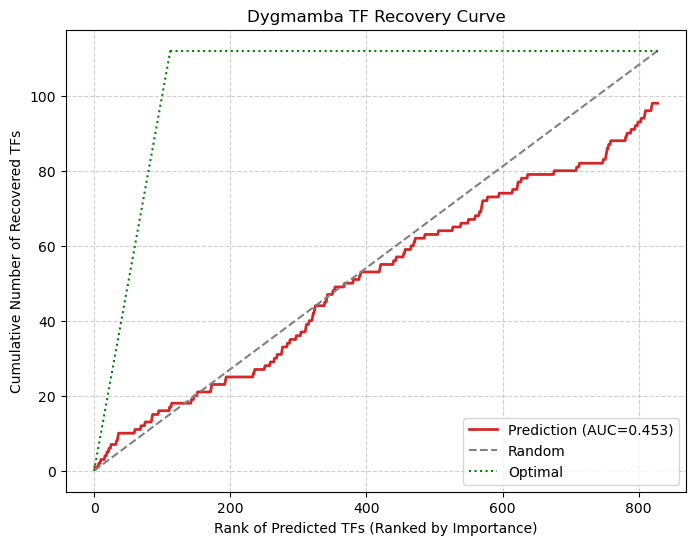

In [ ]:
from analysis.assess import dygmamba_assess, analysis_tf_recovery

threshold_weight_active = 0.3

dyg_avg_active_tf_gene_grn.columns.name = ""
dyg_avg_active_tf_gene_grn = dyg_avg_active_tf_gene_grn.reset_index()
dyg_avg_active_tf_gene_grn = dyg_avg_active_tf_gene_grn.drop(["index"],axis = 1)
# dyg_avg_active_tf_gene_grn["predict_label"] = (dyg_avg_active_tf_gene_grn["average_weight2"]> threshold_weight_active).astype(int)

dyg_merged_data = pd.merge(benchmark_tf_gene_df, dyg_avg_active_tf_gene_grn, on = ["TF", "Gene"], how="outer").fillna(0)
dyg_merged_data["label"] = (dyg_merged_data["value"] > benchmark_tf_gene_threshold).astype(int)
dyg_merged_data["predict_label"] = (dyg_merged_data["avg_weight2"]> threshold_weight_active).astype(int)

dyg_merge_grn = dyg_merged_data.copy()

dyg_y_true = dyg_merge_grn["label"].astype(int)
dyg_y_pre = dyg_merge_grn["predict_label"].astype(int)
dyg_model_name = "Dygmamba"

dyg_dict = dygmamba_assess(dyg_y_true, dyg_y_pre, model_name = dyg_model_name, 
                            beta = beta_value, type = result_type, fig_path = assess_result)

benchmark_result.append(dyg_dict)
    
# dyg_gold_grn, dyg_gold_grn = analysis_tf_recovery(dyg_merged_data, 
#                                                     model_name = dyg_model_name, fig_path = assess_result)

Gold Standard 中共有 112 个唯一 TF。
未检测到分数列，将按 TF 的靶基因数量 (Degree) 进行排序。
save fig as /home/liyang/BioWuYan/MethodTest/assess_result4/Dygmamba_global_TF_recovery_curve.png


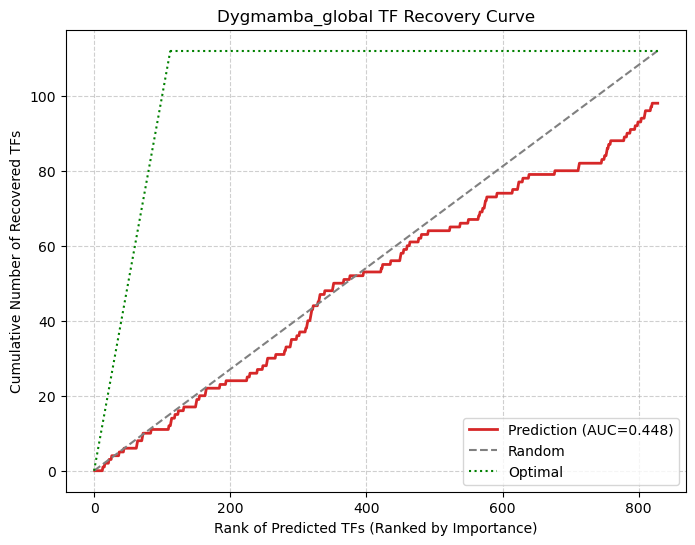

In [ ]:
threshold_weight_global = 0.2

dyg_avg_global_tf_gene_grn.columns.name = ""
dyg_avg_global_tf_gene_grn = dyg_avg_global_tf_gene_grn.reset_index()
dyg_avg_global_tf_gene_grn = dyg_avg_global_tf_gene_grn.drop(["index"],axis = 1)


dyg_global_merged_data = pd.merge(benchmark_tf_gene_df, dyg_avg_global_tf_gene_grn, on = ["TF", "Gene"], how="outer").fillna(0)
dyg_global_merged_data["label"] = (dyg_global_merged_data["value"] > benchmark_tf_gene_threshold).astype(int)
dyg_global_merged_data["predict_label"] = (dyg_global_merged_data["average_active_weight"]> threshold_weight_global).astype(int)

dyg_global_merge_grn = dyg_global_merged_data.copy()

dyg_global_y_true = dyg_global_merge_grn["label"].astype(int)
dyg_global_y_pre = dyg_global_merge_grn["predict_label"].astype(int)
dyg_global_model_name = "Dygmamba" + "_global"

dyg_global_dict = dygmamba_assess(dyg_global_y_true, dyg_global_y_pre, model_name = dyg_global_model_name, 
                            beta = beta_value, type = result_type, fig_path = assess_result)

benchmark_result.append(dyg_global_dict)
    
# dyg_global_gold_grn, dyg_global_gold_grn = analysis_tf_recovery(dyg_global_merged_data, 
#                                                     model_name = dyg_global_model_name, fig_path = assess_result)

# TF-region

In [34]:
benchmark_tf_peak_df = adata_to_dataframe(benchmark_tf_peak_grn)
benchmark_tf_peak_df = benchmark_tf_peak_df.rename(columns= {"obs":"Peak", "var":"TF"})
print(benchmark_tf_peak_df)

dygmamba_data_path = "/home/liyang/BioWuYan/MethodTest/dygmamba/res/result2/"
dygmamba_tf_peak_df = pd.read_pickle(dygmamba_data_path + "tf_region_grn.pkl")
dygmamba_tf_peak_df = dygmamba_tf_peak_df.rename(columns={"value":"predict"})
print(dygmamba_tf_peak_df)

dyg_merged_tf_peak_data = pd.merge(benchmark_tf_peak_df, dygmamba_tf_peak_df, on = ["TF", "Peak"], how="outer").fillna(0)

print(dyg_merged_tf_peak_data)

                             Peak     TF  value
0        chr1-100028461-100029069  CREB1      1
1        chr1-100028461-100029069   CREM      1
2        chr1-100028461-100029069   E2F1      1
3        chr1-100028461-100029069   ETV6      1
4        chr1-100028461-100029069  FOSL1      1
...                           ...    ...    ...
2758834      chrX-9996978-9998203  TBX21      1
2758835      chrX-9996978-9998203  TCF12      1
2758836      chrX-9996978-9998203   TCF3      1
2758837      chrX-9996978-9998203    YY1      1
2758838    chrY-11310224-11310574  CREB1      1

[2758839 rows x 3 columns]


In [59]:
data_path = "/home/liyang/BioWuYan/MethodTest/dygmamba/res/result2/"
benchmark_result = []
result_type = "binary"
beta_value = 1
assess_result = "/home/liyang/BioWuYan/MethodTest/assess_result4/"

dyg_y_true = dyg_merged_tf_peak_data["value"].astype(int)
dyg_y_pre = dyg_merged_tf_peak_data["predict"].astype(int)
dyg_model_name = "Dygmamba_peak"

dyg_dict = dygmamba_assess(dyg_y_true, dyg_y_pre, model_name = dyg_model_name, 
                            beta = beta_value, type = result_type, fig_path = assess_result)

dyg_tf_region_result = pd.DataFrame([dyg_dict])
print(dyg_tf_region_result)

print(f"merged: {len(dyg_merged_tf_peak_data)}, benchmark tf peak: {len(benchmark_tf_peak_df)}, dyg tf peak: {len(dygmamba_tf_peak_df)}")

      model_name  TN        FP      FN       TP  precision    recall  FPR  \
0  Dygmamba_peak   0  52562895  624258  2493495    0.04529  0.799773  1.0   

        AUC   f_score  
0  0.399887  0.085725  
merged: 55680648, benchmark tf peak: 2758839, dyg tf peak: 55056390


# Region-Gene

In [42]:
benchmark_peak_gene_df = adata_to_dataframe(benchmark_peak_gene_grn)
benchmark_peak_gene_df = benchmark_peak_gene_df.rename(columns= {"obs":"Peak", "var":"Gene"})
print(benchmark_peak_gene_df)

dygmamba_peak_gene_df = pd.read_pickle(dygmamba_data_path + "region_gene_grn.pkl")
dygmamba_peak_gene_grn = dygmamba_peak_gene_df[["source", "target", "predict", "ts"]].copy()
dygmamba_peak_gene_grn = dygmamba_peak_gene_grn.rename(columns = {"source":"Peak", "target":"Gene"})
condition =  ~(dygmamba_peak_gene_grn['Gene'].str.startswith('chr'))
dygmamba_peak_gene_grn = dygmamba_peak_gene_grn[condition]
print(dygmamba_peak_gene_grn)

avg_active_peak_gene_grn = dygmamba_peak_gene_grn.groupby(['Peak', 'Gene']).agg(
    avg_ts_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()

print(avg_active_peak_gene_grn)

dyg_merged_peak_gene_data = pd.merge(benchmark_peak_gene_df, avg_active_peak_gene_grn, on = ["Gene", "Peak"], how="outer").fillna(0)

print(dyg_merged_peak_gene_data.head())

                             Peak     Gene  value
0        chr1-100028461-100029069      AGL      1
1        chr1-100028461-100029069     ARNT      1
2        chr1-100028461-100029069     BCL9      1
3        chr1-100028461-100029069     COPA      1
4        chr1-100028461-100029069  CTDSPL2      1
...                           ...      ...    ...
1686605      chrX-9996978-9998203     TLR7      1
1686606      chrX-9996978-9998203    WBP1L      1
1686607      chrX-9996978-9998203     WWC3      1
1686608    chrY-11310224-11310574    KYAT3      1
1686609    chrY-11310224-11310574  SLC35A3      1

[1686610 rows x 3 columns]


In [58]:

dyg_merged_peak_gene_data["predict"] = (dyg_merged_peak_gene_data["avg_ts_weight"]>0.9).astype(int)

dyg_y_true = dyg_merged_peak_gene_data["value"].astype(int)
dyg_y_pre = dyg_merged_peak_gene_data["predict"].astype(int)
dyg_model_name = "Dygmamba_peak_gene"

dyg_dict = dygmamba_assess(dyg_y_true, dyg_y_pre, model_name = dyg_model_name, 
                            beta = beta_value, type = result_type, fig_path = assess_result)

dyg_peak_gene_result = pd.DataFrame([dyg_dict])
print(dyg_peak_gene_result)

print(f"merged: {len(dyg_merged_peak_gene_data)}, benchmark peak gene: {len(benchmark_peak_gene_df)}, dyg peak gene {len(avg_active_peak_gene_grn)}")

           model_name  TN  FP       FN   TP  precision    recall  FPR  AUC  \
0  Dygmamba_peak_gene   0   0  1686168  442        1.0  0.000262  NaN  NaN   

    f_score  
0  0.000524  
merged: 1686610, benchmark peak gene: 1686610, dyg peak gene 442


/home/liyang/BioWuYan/MethodTest/dygmamba/src/analysis/assess.py:56: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
